# #️⃣ TikTok Hashtag Classification Pipeline v2.0

## 🪈 Pipeline Overview

In this notebook, we implement a two-stage pipeline for TikTok hashtag processing:
- **Stage 1**: Data Extraction & Cleaning - Extract hashtags from video descriptions, handle malformed hashtags (jammed or spaced), and clean the data
    
- **Stage 2**: Data Preprocessing - Use fuzzy matching to group misspelled variations together and create parent-child hashtag relationships with semantic verification

We successfully processes ~7 million TikTok video descriptions to:
- Extract and clean 38+ million hashtag instances
- Identify 2.56 million unique hashtags
- Group similar hashtags using fuzzy matching and semantic verification, leading to 1.64 million unique parent hashtags (36% reduction)
- Create a structured dataset with parent-child relationships for analysis

The combination of string matching (Jaro distance) and semantic matching (embedding-based) ensures that grouped hashtags are both textually similar and conceptually related.

---

## 🐍 Stage 0: Setup

### Imports

NOTE: Python 3.11, `pyarrow` downgraded to `v20.0`

In [ ]:
# Standard library imports
import gc
import pickle
import re
import nltk
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import Levenshtein
import rapidfuzz
from nltk.corpus import words, wordnet
from collections import defaultdict
from itertools import combinations
from pathlib import Path
from time import time
from sklearn.metrics.pairwise import cosine_similarity

# Third-party imports
import numpy as np
import pandas as pd
import sqlite3
from tqdm import tqdm
from rapidfuzz import process, fuzz
from datasketch import MinHash
from sentence_transformers import SentenceTransformer

# Local application imports
from config import PROJECT_ROOT, DB_DIR, DATA_PREP_DIR, FIGURES_DIR, DB_PATH, HASHTAG_DF_PATH

---

## 🧼 Step 1: Data Extraction and Cleaning

### SQL Connection

In [ ]:
# Database connection
conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

In [4]:
# Load data from the SQLite database
with sqlite3.connect(DB_PATH) as conn:
    hashtag_df = pd.read_sql_query("SELECT description, id FROM videos", conn) # load the 'description' and 'id' columns

### Hashtag Extraction

In [5]:
# Check how many videos have '#' in the description
num_with_hashes = hashtag_df['description'].str.contains('#').sum()
total_descriptions = len(hashtag_df)
print(f"Out of {total_descriptions} descriptions, {num_with_hashes} contain hash (#) symbols followed by a non-whitespace character ({(num_with_hashes/total_descriptions)*100:.2f}%).\n")

Out of 7054736 descriptions, 5601752 contain hash (#) symbols followed by a non-whitespace character (79.40%).



In [6]:
# Check how many videos contain valid hashtags
# hashtag followed by alphanumeric characters or emoji (no spaces)
hashtag_pattern_valid = re.compile(r'#\S+')    # Matches hashtags like #example or #😊
# hashtag followed by space(s) and then alphanumeric characters or emoji (intended hashtags with space) EXCEPT another '#' (so '# #' is not matched)
hashtag_pattern_intended = re.compile(r'#\s+(?!#)\S+')


def contains_valid_hashtag(description):
    if pd.isna(description):
        return False
    return bool(hashtag_pattern_valid.search(description) or hashtag_pattern_intended.search(description))

valid_hashtags = hashtag_df['description'].apply(contains_valid_hashtag)
print(f"Out of {total_descriptions} descriptions, {valid_hashtags.sum()} contain valid hashtags ({(valid_hashtags.sum()/total_descriptions)*100:.2f}%).\n")

# Print 10 examples of descriptions with valid hashtags
print("Examples of descriptions with valid hashtags:")
for desc in hashtag_df[valid_hashtags]['description'].dropna().sample(6, random_state=42):
    print(f"- {desc}")  

# Print 10 examples of descriptions with '#' but no valid hashtags
print("\nExamples of descriptions with '#' but no valid hashtags:")
invalid_hashtags = hashtag_df['description'].str.contains('#') & ~valid_hashtags
for desc in hashtag_df[invalid_hashtags]['description'].dropna().sample(6, random_state=42):
    print(f"- {desc}")

# Add a new column to the DataFrame indicating presence of valid hashtags
hashtag_df['hashtag_present'] = valid_hashtags

Out of 7054736 descriptions, 5601392 contain valid hashtags (79.40%).

Examples of descriptions with valid hashtags:
- #coldplay Amsterdam
- His impression was SPOT ON 👌😂 (@itsmadshope) #pubity #harrypotter 
- The case of male medical students exposing themselves & rushing the court at a Brazilian University after a female volleyball team wins a game #fy #fyp #foryou 
- literally the best purchase ever #digitalcamera #kodakpixpro #adapter #amazonfinds 
- 😭😭AAN ALLES KOMT EEN EIND😭😭 #fifa #royalistiq #fyp #fy #viral 
- gims est-ce que tu m'aimes  #explor #تصميم_فيديوهات🎶🎤🎬 #كيتمان_اجباري🎧 #تصميمي❤️ #editlyrics #🇲🇦 #parole #vypシ #موسيقى #slowed #viral #pourtoi #foryou #tiktok #explore #viralvideo #🇲🇦🇩🇿🇹🇳 #شعب_الصيني_ماله_حل😂😂 #capcut_edit 

Examples of descriptions with '#' but no valid hashtags:
- Crystal palace have zero respect to their opponents #
- Whooooellasimprefeliz#
- #
- use this sound for fyp #
- It’s because we see potential! Corrections are a great thing! 👏🏼 #
- #


### Cleaning

#### Fix intended hashtags (i.e., `# tag` -> `#tag`)

In [7]:
contains_intended_hashtag = hashtag_df['description'].apply(lambda x: bool(hashtag_pattern_intended.search(x)) if pd.notna(x) else False)
print(f"\nOut of {total_descriptions} descriptions, {contains_intended_hashtag.sum()} contain intended hashtags ({(contains_intended_hashtag.sum()/total_descriptions)*100:.2f}%).\n")


Out of 7054736 descriptions, 3023 contain intended hashtags (0.04%).



In [8]:
# Fix intended hashtags by removing spaces after '#'
def fix_intended_hashtags(description):
    if pd.isna(description):
        return description
    return hashtag_pattern_intended.sub(lambda m: '#' + m.group(0).lstrip('#').lstrip(), description)

hashtag_df['fixed_description'] = hashtag_df['description'].apply(fix_intended_hashtags)

In [9]:
# how many rows where the description was changed
num_fixed = (hashtag_df['description'] != hashtag_df['fixed_description']).sum()
print(f"Fixed {num_fixed} descriptions by removing spaces after '#'.\n")

# Show 6 examples of original and fixed descriptions
print("Examples of original and fixed descriptions:")
for original, fixed in hashtag_df[hashtag_df['description'] != hashtag_df['fixed_description']][['description', 'fixed_description']].dropna().sample(6, random_state=42).itertuples(index=False):
    print(f"- Original: {original}\n  Fixed:    {fixed}\n")

# Clean up memory
del valid_hashtags, contains_intended_hashtag, invalid_hashtags
gc.collect()

Fixed 3023 descriptions by removing spaces after '#'.

Examples of original and fixed descriptions:
- Original: #spelldesigns #multiplesclerosis #msfighter #mswarrior #nstafashion #spellmo #styleme #spellsisters #OOTD #socalates #bohovibe #bohin #spellsisters #OOTD #socal #bohovibe #boho #spellandthegypsycollective #spellandthegypsy #spellthelabel #hibiscus #hibiscusmini #hibiscuskimono #kimono #lovespells #lovespells #lovespellsmaster #lovespell #lovespells #Love #love _spell# lovespelling #lovespelljar #lovespelljars #obsessionlovespell #lovespellbridal # lovespellsmaster #spelllove #spell #loveattractionspell #lovespell #lovespellsalon # #honeylovespell #lovebindingspell #soulmate #spellattractyourlove #plantsforlovespells #outforlove #forlove #spelljarforhealth #spellforlovek #spellforlovesake #spelljarforbegginers #lovespellforwealth #lovespellforcouple #lovespellforprotection #lovesspelltoattractyourlove #searchingforlove #readyforlove #standupforlove #spelljarformoney #casterfor

39

#### Fix jammed hashtags (i.e., `#tags#too#close` -> `#tags, #too, #close`)

In [10]:
# Extract strings that start with '#' and are followed by characters (no spaces)
hashtag_df['hashtags'] = (
    hashtag_df['fixed_description']
    .str.split() # split descriptions along whitespaces
    .apply(lambda words: [word[1:] for word in words if word.startswith('#')]) # extract strings starting with '#', remove '#'
)

print(f"Found {hashtag_df['hashtags'].apply(len).sum()} hashtags in total.")

Found 37226146 hashtags in total.


In [11]:
# Split jammed hashtags in the 'hashtags' column (e.g., 'tag1#tag2' -> ['tag1', 'tag2'])
def split_jammed_hashtags(hashtags_list):
    split_tags = []
    for tag in hashtags_list:
        split_tags.extend([t for t in tag.split('#') if t])
    return split_tags

hashtag_df['split_hashtags'] = hashtag_df['hashtags'].apply(split_jammed_hashtags)


In [12]:
# Check how many rows had jammed hashtags
num_jammed = (hashtag_df['hashtags'] != hashtag_df['split_hashtags']).sum()
print(f"Split jammed hashtags in {num_jammed} descriptions.\n")
print(f"Total hashtags after splitting jammed ones: {hashtag_df['split_hashtags'].apply(len).sum()}.\n")

# Show 6 examples of jammed and fixed hashtags
print("Examples of jammed and fixed hashtags:")
for original, fixed in hashtag_df[hashtag_df['hashtags'] != hashtag_df['split_hashtags']][['hashtags', 'split_hashtags']].sample(6, random_state=42).itertuples(index=False):
    print(f"- Jammed: {original}\n  Fixed:  {fixed}\n")

# Clean up memory
del original, fixed
gc.collect()

Split jammed hashtags in 191114 descriptions.

Total hashtags after splitting jammed ones: 38044149.

Examples of jammed and fixed hashtags:
- Jammed: ['fashion#Style']
  Fixed:  ['fashion', 'Style']

- Jammed: ['systemofadown', 'fypシ#fy#foryou', 'therian', 'metalhead', 'metal']
  Fixed:  ['systemofadown', 'fypシ', 'fy', 'foryou', 'therian', 'metalhead', 'metal']

- Jammed: ['baking#bodyandfit#findyourfit#healthyrecipes#recipe#cookiedough#gingerbread#christmasrecipe#food']
  Fixed:  ['baking', 'bodyandfit', 'findyourfit', 'healthyrecipes', 'recipe', 'cookiedough', 'gingerbread', 'christmasrecipe', 'food']

- Jammed: ['PRECURE20TH', 'precuresongoftheday', 'precure', 'precure20thanniversary', 'curefinale#hugttoprecure']
  Fixed:  ['PRECURE20TH', 'precuresongoftheday', 'precure', 'precure20thanniversary', 'curefinale', 'hugttoprecure']

- Jammed: ['windbreakerwebtoon', 'windbreaker', 'wooin', 'joker', 'hyuk#edit', 'windbreakerwebtoon', 'fypシ']
  Fixed:  ['windbreakerwebtoon', 'windbreaker'

31

#### Save extracted hashtags

In [ ]:
## Wrap up
# Keep only fixed hashtags and IDs
final_df = hashtag_df[['split_hashtags', 'id']].dropna().reset_index(drop=True).copy()
del hashtag_df
gc.collect()

# Drop rows where 'split_hashtags' is empty
final_df = final_df[final_df['split_hashtags'].apply(len) > 0].reset_index(drop=True)

# Rename `split_hashtags` to `hashtags`
final_df = final_df.rename(columns={'split_hashtags': 'hashtags'})
print(f"Number of videos with valid hashtags: {final_df.shape[0]}.")

# Save the final DataFrame to a pickle file
output_path = DATA_PREP_DIR / "extracted_hashtags.pkl"
with open(output_path, 'wb') as f:
    pickle.dump(final_df, f)

Number of videos with valid hashtags: 5561559.


---

## 🪄 Step 2: Data Preprocessing

### Data loading

In [ ]:
# Load the final DataFrame from the pickle file (for verification)
with open(DATA_PREP_DIR / "extracted_hashtags.pkl", 'rb') as f:
    hashtag_and_id_df = pickle.load(f)
print(f"Loaded DataFrame from pickle with {len(hashtag_and_id_df)} rows.")

In [4]:
# Put IDs aside until final step
hashtag_df = hashtag_and_id_df[['hashtags']].copy()

#### Get hashtag count data

In [5]:
# Get hashtag frequencies
hashtag_df_exploded = hashtag_df.explode('hashtags').reset_index(drop=True)
hashtag_counts = hashtag_df_exploded['hashtags'].value_counts().reset_index()
hashtag_counts.columns = ['hashtag', 'frequency']

# Check if there are any NaN values in the 'hashtags' column
if hashtag_df_exploded['hashtags'].isna().any():
    print("There are NaN values in the 'hashtags' column.")
print(f"Total unique hashtags: {len(hashtag_counts)}")

del hashtag_df_exploded
gc.collect()

Total unique hashtags: 2561760


0

### 🪄 Group similar hashtags

#### 🤝 Helper functions

In [8]:
def _check_english(hashtag_counts):
    """Check which hashtags are valid English words."""
    
    # import enchant
    # d_US = enchant.Dict("en_US")
    # d_UK = enchant.Dict("en_GB")

    def is_word_in_wordnet(word):
        return bool(wordnet.synsets(word))
    
    # Create a set of English words for quick lookup
    word_set = set(words.words())

    # Create alphanumeric-only hashtags column
    hashtag_counts['hashtag_alnum'] = hashtag_counts['hashtag'].apply(lambda x: re.sub(r'[^a-zA-Z0-9]', '', x))

    print("Checking which hashtags are valid English words...")
    # Check if hashtag_alnum is a valid English word
    hashtag_counts['is_english_alnum_words'] = hashtag_counts['hashtag_alnum'].apply(lambda x: x.lower() in word_set) 
    hashtag_counts['is_english_alnum_wordnet'] = hashtag_counts['hashtag_alnum'].apply(lambda x: is_word_in_wordnet(x.lower()))
    hashtag_counts['is_real_english_alnum_word'] = (
        hashtag_counts['is_english_alnum_words'] |
        hashtag_counts['is_english_alnum_wordnet']
    )

    english_hashtags = set(
        hashtag_counts[hashtag_counts['is_real_english_alnum_word']]['hashtag'].tolist()
    )

    return hashtag_counts, english_hashtags

In [9]:
def _lemmatize_hashtags(hashtag_counts):
    """Lemmatize English alphanumeric hashtags."""

    # Create a WordNetLemmatizer instance
    lemmatizer = nltk.WordNetLemmatizer()

    # Function to get the part of speech tag for lemmatization
    def get_wordnet_pos(word):
        tag = nltk.pos_tag([word])[0][1][0].upper()
        tag_dict = {"J": wordnet.ADJ, "N": wordnet.NOUN, "V": wordnet.VERB, "R": wordnet.ADV}
        return tag_dict.get(tag, wordnet.NOUN)

    print("Lemmatizing English alphanumeric hashtags...")
    # For hashtags that are valid English words, get lemmatized forms; for others, keep None
    hashtag_counts['lemmatized_english_alnum_hashtag'] = hashtag_counts.apply(
        lambda row: lemmatizer.lemmatize(
            row['hashtag_alnum'].lower(),
            get_wordnet_pos(row['hashtag_alnum'])
        ) if row['is_real_english_alnum_word'] else None,
        axis=1
    )

    # Create dictionary of lemmatized forms for quick lookup
    lemmatized_map = hashtag_counts.set_index('hashtag')['lemmatized_english_alnum_hashtag'].to_dict()

    # Keep only entries with lemmatized forms
    lemmatized_map = {k: v for k, v in lemmatized_map.items() if v is not None}

    return hashtag_counts, lemmatized_map

In [10]:
def _embed_lemmatized_hashtags(lemmatized_map, model='all-MiniLM-L12-v2'):
    # Set up SentenceTransformer model
    lemma_batch_size = 512
    model = SentenceTransformer(model)
    lemmatized_embeddings = {}

    # Embed lemmatized forms in batches
    print ("Embedding lemmatized forms...")
    for i in tqdm(range(0, len(lemmatized_map), lemma_batch_size), desc="Computing lemmatized embeddings"):

        # Get batch of potential parent hashtags
        batch_end = min(i + lemma_batch_size, len(lemmatized_map))
        batch_keys = list(lemmatized_map.keys())[i:batch_end]

        batch_lemmas = [lemmatized_map[k] for k in batch_keys]
        batch_embeddings = model.encode(batch_lemmas, convert_to_tensor=False, show_progress_bar=False)

        # Store lemmatized embeddings
        for key, embedding in zip(batch_keys, batch_embeddings):
            lemmatized_embeddings[key] = embedding

    # Convert embeddings dict to aligned arrays
    lemmatized_hashtag_list = list(lemmatized_embeddings.keys())
    embedding_matrix = np.array([lemmatized_embeddings[ht] for ht in lemmatized_hashtag_list])

    return lemmatized_embeddings, lemmatized_hashtag_list, embedding_matrix

#### 🧸 Fuzzy string matching

In [11]:
# Make parent hashtag column in df for grouping similar hashtags
hashtag_counts['parent_hashtag'] = None

In [12]:
def group_similar_hashtags(hashtag_counts, batch_size=128, threshold=0.9, num_workers=6, model='all-MiniLM-L12-v2'):
    """
    Group similar hashtags using fuzzy matching with improved memory and performance.
    
    Args:
        hashtag_counts: DataFrame with 'hashtag' and 'parent_hashtag' columns
        batch_size: Number of hashtags to process per batch
        threshold: Similarity threshold (0-1)
    
    Returns:
        Modified hashtag_counts DataFrame
    """

    ## Efficient assignment tracking
    print("Extracting unassigned hashtags...")
    unassigned_hashtags = set(hashtag_counts[hashtag_counts['parent_hashtag'].isna()]['hashtag'].tolist()) # Use a set for efficient lookups of unassigned hashtags
    parent_map = hashtag_counts.set_index('hashtag')['parent_hashtag'].to_dict() # Create a dictionary efficient parent-child lookups and assignments
    all_hashtags = hashtag_counts['hashtag'].tolist() # Get all hashtags as a list for batching
    total_assigned = 0 # Track total assignments for progress reporting

    ## Set up English word checking and lemmatization
    hashtag_counts, english_hashtags = _check_english(hashtag_counts) # English word checking
    hashtag_counts, lemmatized_map = _lemmatize_hashtags(hashtag_counts) # Lemmatization (i.e., given an English hashtag, reduce it to its base, dictionary form (e.g., "eating", "eats", "ate" -> "eat"))
    lemmatized_embeddings,lemmatized_hashtag_list, embedding_matrix = _embed_lemmatized_hashtags(lemmatized_map, model=model) # Embedding lemmatized forms

    # Free memory
    hashtag_counts.drop(columns=['is_english_alnum_words', 'is_english_alnum_wordnet'], inplace=True)
    
    for i in tqdm(range(0, len(all_hashtags), batch_size), desc="Batch fuzzy grouping"):
        # Get batch of potential parent hashtags; filter to only unassigned hashtags
        batch_end = min(i + batch_size, len(all_hashtags))
        batch_candidates = all_hashtags[i:batch_end]
        parent_hashtags_batch = [
            ht for ht in batch_candidates 
            if ht in unassigned_hashtags
        ]

        print(f"\nProcessing batch {i//batch_size + 1}: {len(parent_hashtags_batch)} unassigned hashtags")
        
        # Skip empty batches
        if not parent_hashtags_batch:
            print("No unassigned hashtags in this batch, skipping.")
            continue
        
        # Compute similarities only with remaining unassigned hashtags
        unassigned_list = list(unassigned_hashtags) # Convert unassigned set to list for cdist
        similarities = np.triu(
            process.cdist(
                parent_hashtags_batch, 
                unassigned_list,
                scorer=jaro,
                score_cutoff=threshold,
                workers=num_workers
            )
        )
        
        # Process each parent hashtag and update unassigned list immediately
        batch_all_assignments = {}  # Track all assignments for bulk DataFrame update
        
        for col_idx, parent in enumerate(parent_hashtags_batch):
            # If parent already has a parent assigned, skip to avoid cycles
            if parent not in unassigned_hashtags:
                print(f"'{parent}' already assigned as child elsewhere, skipping to avoid cycles.")
                continue

            # If parent has less than 3 characters, skip to avoid spurious matches
            if len(parent) < 3:
                continue

            # Check if parent is a valid English hashtag
            parent_is_english = parent in english_hashtags

            # If yes, compute semantic similarities between parent and children
            if parent_is_english:
                parent_embedding = lemmatized_embeddings.get(parent).reshape(1, -1)
                cosine_similarities = cosine_similarity(parent_embedding, embedding_matrix)

            # Find similar hashtags above threshold in the CURRENT unassigned list
            # Need to remap indices because unassigned_list may have changed
            current_unassigned_set = unassigned_hashtags
            
            # Get indices relative to the original unassigned_list
            similar_indices = np.where(similarities[col_idx, :] >= threshold)[0]

            if len(similar_indices) == 0:
                continue
            
            # Get similar hashtags, but only those still in unassigned set
            similar_hashtags = [
                unassigned_list[idx] for idx in similar_indices 
                if unassigned_list[idx] in current_unassigned_set
            ]
            
            if not similar_hashtags:
                continue
            
            # print(f"'{parent}' matched with {len(similar_hashtags)} hashtags")
            
            # Store assignments for bulk DataFrame update
            for child in similar_hashtags:
                if parent_is_english:
                    if child in english_hashtags: # If both parent and child are English, check if lemmatized forms are similar enough
                        # Get cosine similarity between potential parent-child pairs
                        parent_child_similarity = cosine_similarities[0][lemmatized_hashtag_list.index(child)]

                        # Moderate similarity, further check required:
                        if parent_child_similarity >= 0.70 and parent_child_similarity < 0.85:
                            # print(f"Questionable assignment '{parent}': '{child}'. Lemmatized forms have moderate similarity. Score: {parent_child_similarity:.3f}")
                            parent_lemma = lemmatized_map.get(parent)
                            child_lemma = lemmatized_map.get(child)
                            # If lemmatized forms do not match, skip assignment
                            if parent_lemma != child_lemma:
                                # print(f"Lemmatized forms do not match ('{parent_lemma}' != '{child_lemma}'). Skipping.")
                                # Remove child from similar_hashtags so that it can be reconsidered in future batches
                                similar_hashtags.remove(child)
                                continue
                            else:
                                print(f"Lemmatized forms match ('{parent_lemma}' == '{child_lemma}'). Proceeding with assignment.")
                        
                        # Low similarity, skip assignment
                        elif parent_child_similarity < 0.70:
                            # print(f"Skipping assignment of '{child}' to '{parent}' – lemmatized forms are too dissimilar. Score: {parent_child_similarity:.3f}")
                            # Remove child from similar_hashtags so that it can be reconsidered in future batches
                            similar_hashtags.remove(child)
                            continue
                        
                # Store assignments
                batch_all_assignments[child] = parent
            
            # Remove assigned hashtags from unassigned set
            unassigned_hashtags -= set(similar_hashtags)
            
            # Update parent map
            for child in similar_hashtags:
                parent_map[child] = parent
            
            total_assigned += len(similar_hashtags)
        
        # Apply all assignments from this batch to DataFrame at once
        if batch_all_assignments:
            mask = hashtag_counts['hashtag'].isin(batch_all_assignments.keys())
            hashtag_counts.loc[mask, 'parent_hashtag'] = (
                hashtag_counts.loc[mask, 'hashtag'].map(batch_all_assignments)
            )
            
            print(f"Assigned {len(batch_all_assignments)} hashtags in this batch (total: {total_assigned})")
    
    print(f"\nCompleted: {total_assigned} total assignments, {len(unassigned_hashtags)} remain unassigned")
    
    return hashtag_counts

In [ ]:
group_similar_hashtags(hashtag_counts, batch_size=8192, threshold=0.9, num_workers=48, model="Qwen/Qwen3-Embedding-0.6B")

In [ ]:
# For all hashtags that don't have a parent (i.e., hashtags with two characters), set the parent to itself
hashtag_counts['parent_hashtag'] = hashtag_counts.apply(
    lambda row: row['hashtag'] if pd.isna(row['parent_hashtag']) else row['parent_hashtag'],
    axis=1
)

In [ ]:
# Save
hashtag_counts.to_csv(DATA_PREP_DIR / "full_parented.csv", index=False)

### 🧭 Step 3: Exploration

#### 🧑‍🧒‍🧒 Explore parent-child relationships

In [3]:
# Load from CSV
hashtag_counts = pd.read_csv(DATA_PREP_DIR / "full_parented.csv")

In [4]:
# How many unique parents?
print(f"Total unique parent hashtags: {hashtag_counts['parent_hashtag'].nunique()}")
print(f"Total hashtags: {len(hashtag_counts)}")
print(f"Reduction of {(1 - hashtag_counts['parent_hashtag'].nunique() / len(hashtag_counts)) * 100:.2f}% in unique hashtags after grouping.")

Total unique parent hashtags: 1660232
Total hashtags: 2561760
Reduction of 35.19% in unique hashtags after grouping.


In [8]:
# Create a new DataFrame with only parent hashtags, the number of children, and the children in a list
parent_hashtag_df = (
    hashtag_counts
    .groupby('parent_hashtag')
    .agg(
        num_children=('hashtag', 'count'),
        children=('hashtag', lambda x: x.tolist())
    )
    .reset_index()
)

# Sort by number of children descending
parent_hashtag_df = parent_hashtag_df.sort_values(by='num_children', ascending=False).reset_index(drop=True)

In [9]:
parent_hashtag_df.head()

,parent_hashtag,num_children,children
0,foryoupage,662,"[foryoupage, foryourpage, foryoupage❤️❤️, foru..."
1,cosplay,378,"[cosplay, cosplayer, codcosplay, Cosplay, cosp..."
2,tiktok,368,"[tiktok, f1tiktok, tiktoknl, hptiktok, tiktoke..."
3,genshinimpact,356,"[genshinimpact, genshinimpactedit, genshinimpa..."
4,taylorswift,320,"[taylorswift, taylorswiftedit, taylorswifttok,..."


In [10]:
# Save to .csv
parent_hashtag_df.to_csv(DATA_PREP_DIR / "parented_hashtags_summary.csv", index=False)

In [18]:
# How many parents have only 1 child?
parent_child_counts = hashtag_counts.groupby('parent_hashtag').size().reset_index(name='child_count')
single_child_parents = parent_child_counts[parent_child_counts['child_count'] == 1]
single_child_percent = (len(single_child_parents) / len(parent_child_counts)) * 100
print(f"Total parents with only 1 child: {len(single_child_parents)} out of {len(parent_child_counts)} parents ({single_child_percent:.2f}%).")

# How many parents with at least 2 children?
two_plus_children = parent_child_counts[parent_child_counts['child_count'] >= 2]
print(f"Total parents with at least 2 children: {len(two_plus_children)} out of {len(parent_child_counts)} parents ({100 - single_child_percent:.2f}%).")

# Mean number of children per parent
average_children = parent_child_counts['child_count'].mean()
print(f"Mean number of children per parent hashtag: {average_children:.2f}")

# Mean number if excluding single-child parents
average_children_two_plus = two_plus_children['child_count'].mean()
print(f"Mean number of children per parent hashtag (excluding single-child parents): {average_children_two_plus:.2f}")

Total parents with only 1 child: 1292282 out of 1660232 parents (77.84%).
Total parents with at least 2 children: 367950 out of 1660232 parents (22.16%).
Mean number of children per parent hashtag: 1.54
Mean number of children per parent hashtag (excluding single-child parents): 3.45


In [19]:
# Show sorted parent-child counts
parent_child_counts_sorted = parent_child_counts.sort_values(by='child_count', ascending=False)
parent_child_counts_sorted.head(10)

,parent_hashtag,child_count
614115,foryoupage,662
434466,cosplay,378
1431431,tiktok,368
647597,genshinimpact,356
1388252,taylorswift,320
1354859,strangerthings,298
1507878,viral,287
608885,football,266
613850,foryou,261
389677,challenge,253


#### 🎥 Relink to videos

In [ ]:
# Replace original hashtags with their parent hashtags in the final DataFrame
parent_map = hashtag_counts.set_index('hashtag')['parent_hashtag'].to_dict()
hashtag_parented_df = hashtag_and_id_df.copy()
hashtag_parented_df['hashtags_parented'] = hashtag_parented_df['hashtags'].apply(
    lambda tags: [parent_map.get(tag, tag) for tag in tags] if isinstance(tags, list) else tags
)

# Run .set() on the 'hashtags_parented' column to remove introduced duplicates
hashtag_parented_df['hashtags_parented'] = hashtag_parented_df['hashtags_parented'].apply(
    lambda x: list(set(x)) if isinstance(x, list) else x
)


In [ ]:
hashtag_parented_df.head()

In [15]:
# How many hashtags on average per video before parenting?
average_hashtags_before = hashtag_parented_df['hashtags'].apply(lambda x: len(x) if isinstance(x, list) else 0).mean()
average_hashtags_before_sd = hashtag_parented_df['hashtags'].apply(lambda x: len(x) if isinstance(x, list) else 0).std()
print(f"Average hashtags per video before parenting: {average_hashtags_before:.2f} (SD: {average_hashtags_before_sd:.2f})")

# How many hashtags on average per video after parenting?
average_hashtags_after = hashtag_parented_df['hashtags_parented'].apply(lambda x: len(x) if isinstance(x, list) else 0).mean()
average_hashtags_after_sd = hashtag_parented_df['hashtags_parented'].apply(lambda x: len(x) if isinstance(x, list) else 0).std()
print(f"Average hashtags per video after parenting: {average_hashtags_after:.2f} (SD: {average_hashtags_after_sd:.2f})")

Average hashtags per video before parenting: 6.84 (SD: 6.23)
Average hashtags per video after parenting: 6.44 (SD: 5.17)


#### 📊 Plots

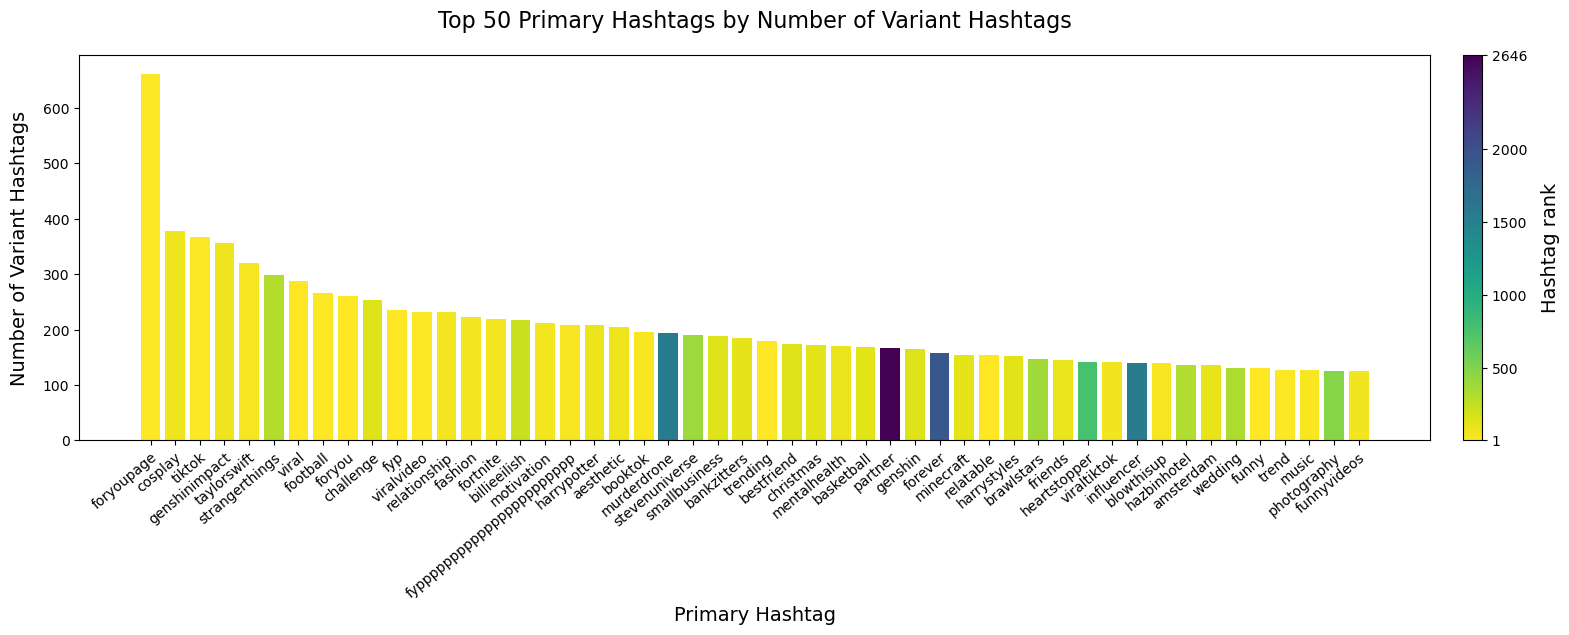

In [ ]:
# Get ranks for parent hashtags based on their idx in hashtag_counts
parent_ranks = hashtag_counts.set_index('hashtag')['frequency'].rank(method='min', ascending=False).astype(int).to_dict()

# Prepare data for plotting
N_parent = 50
top_N_parents = hashtag_counts['parent_hashtag'].value_counts().head(N_parent)
top_N_ranks = [parent_ranks.get(ht, None) for ht in top_N_parents.index]

# Map ranks to colors
rank_vals = np.array(top_N_ranks, dtype=float)
norm = mpl.colors.Normalize(vmin=rank_vals.min(), vmax=rank_vals.max())
cmap = plt.get_cmap('viridis_r')
colors = cmap(norm(rank_vals))

plt.figure(figsize=(21, 5))
bars = plt.bar(top_N_parents.index, top_N_parents.values, color=colors)
plt.xticks(rotation=40, ha='right', rotation_mode='anchor')
plt.xlabel("Primary Hashtag", fontsize=14)
plt.ylabel("Number of Variant Hashtags", fontsize=14, labelpad=10)
plt.title(f"Top {N_parent} Primary Hashtags by Number of Variant Hashtags", fontsize=16, pad=20)

# Add colorbar showing rank mapping (1 = most frequent hashtag)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), pad=0.02, )
cbar.set_label('Hashtag rank', fontsize=14, labelpad=10)

# # Ensure tick "0" appears on the colorbar
cbar.set_ticks([1, 500, 1000, 1500, 2000, rank_vals.max()])

# Savefig
plt.savefig(FIGURES_DIR / f"top_{N_parent}_primary_hashtags_by_number_of_variant_hashtags_with_rank_colorbar.png", bbox_inches='tight', dpi=300)

/var/folders/s5/g1hg90m93rz7hcdy_g2wr0_00000gn/T/ipykernel_21131/4264492847.py:30: UserWarning: Glyph 12471 (\N{KATAKANA LETTER SI}) missing from font(s) DejaVu Sans.
  plt.savefig(FIGURES_DIR / f"top_{N_parent}_hashtags_by_frequency_and_number_of_children.png", bbox_inches='tight', dpi=300)
/var/folders/s5/g1hg90m93rz7hcdy_g2wr0_00000gn/T/ipykernel_21131/4264492847.py:30: UserWarning: Glyph 12442 (\N{COMBINING KATAKANA-HIRAGANA SEMI-VOICED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(FIGURES_DIR / f"top_{N_parent}_hashtags_by_frequency_and_number_of_children.png", bbox_inches='tight', dpi=300)


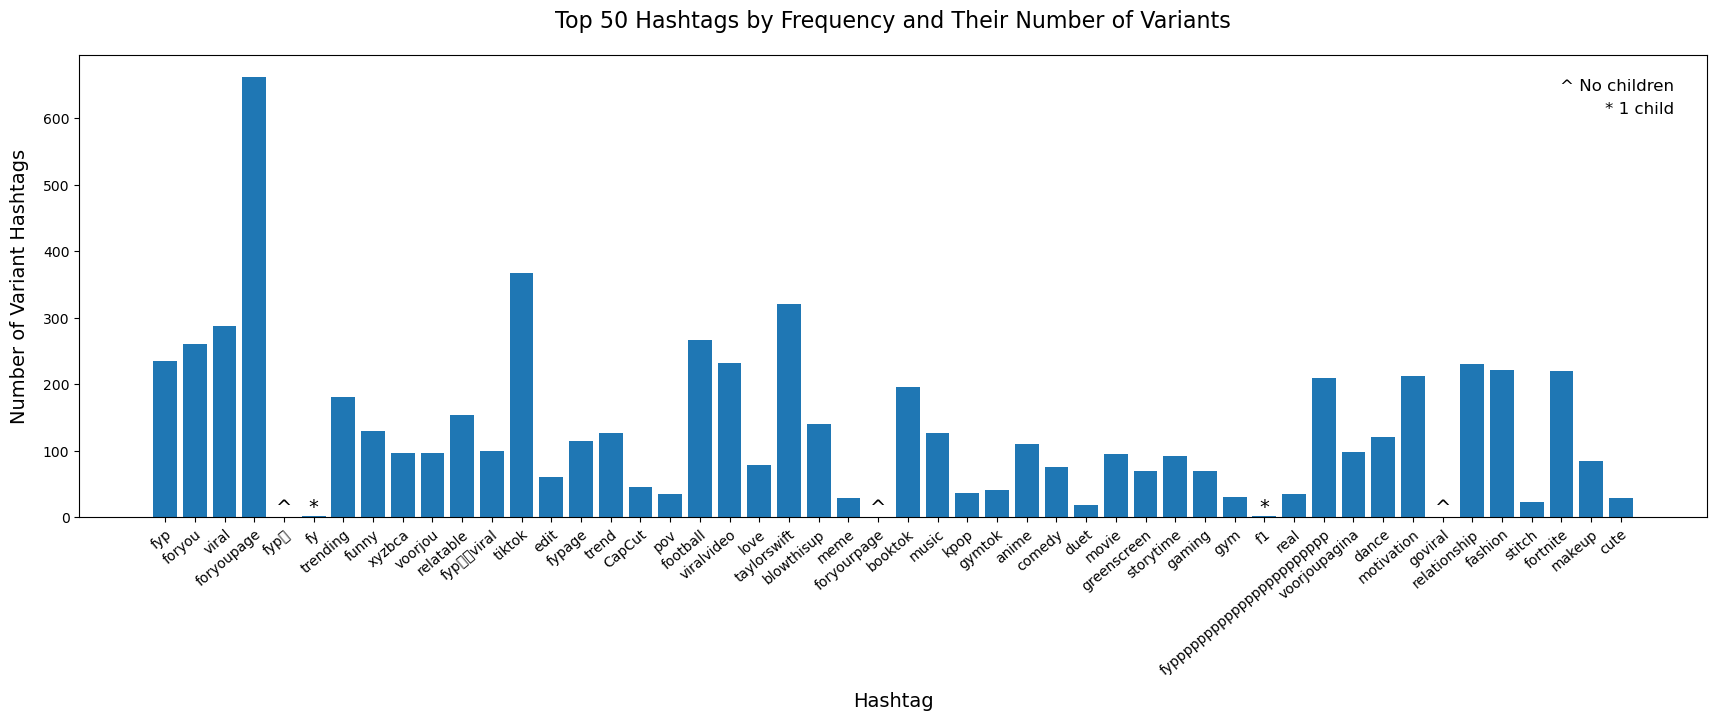

In [ ]:
# Top N hashtags by frequency and their # of children
N_parent = 50
top_N_before = hashtag_counts.head(N_parent)
top_N_children_counts = []

for ht in top_N_before['hashtag']:
    num_children = len(hashtag_counts[hashtag_counts['parent_hashtag'] == ht])
    top_N_children_counts.append(num_children)

plt.figure(figsize=(21, 6))
bars = plt.bar(top_N_before['hashtag'], top_N_children_counts)
plt.xticks(rotation=40, ha='right', rotation_mode='anchor')
plt.xlabel("Hashtag", fontsize=14, labelpad=10)
plt.ylabel("Number of Variant Hashtags", fontsize=14, labelpad=10)
plt.title(f"Top {N_parent} Hashtags by Frequency and Their Number of Variants", fontsize=16, pad=20)

# If a bar has 0 children, add a red "*" above it
for bar, num_children in zip(bars, top_N_children_counts):
    if num_children == 0:
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), "^", ha='center', va='bottom', fontsize=14, color='black')
    # If a bar has 1 child, add a purple "*" above it
    elif num_children == 1:
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), "*", ha='center', va='bottom', fontsize=14, color='black')
    
# Legend for "*" and "^"
plt.text(0.98, 0.90, "* 1 child", transform=plt.gca().transAxes, ha='right', va='top', fontsize=12, color='black')
plt.text(0.98, 0.95, "^ No children", transform=plt.gca().transAxes, ha='right', va='top', fontsize=12, color='black')

# Savefig
plt.savefig(FIGURES_DIR / f"top_{N_parent}_hashtags_by_frequency_and_number_of_children.png", bbox_inches='tight', dpi=300)